# Предиктивное обслуживание промышленного оборудования

**База данных:** `manufacturing`, PostgreSQL 16  
**Единица наблюдения:** машина и окончание часового интервала  
**Цель:** `failure_next_6h` — произойдёт ли `BREAKDOWN` в следующие 6 часов.

Ноутбук выполняет загрузку выгрузки SQL VIEW, проверку качества, обоснованную
очистку, исследовательский анализ, визуализацию и проверку гипотез. Признаки
рассчитаны только по информации, доступной до момента прогноза.


## 1. Подключение библиотек

Для анализа используются `pandas`, `numpy`, `matplotlib`, `seaborn` и
статистические функции `scipy`. Фиксированный стиль графиков делает результаты
воспроизводимыми.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
RANDOM_STATE = 42


## 2. Загрузка CSV

В Google Colab загрузите файл `manufacturing_ml_dataset.csv` через панель
**Files**. Ячейка также предложит загрузку автоматически, если файл не найден.


In [2]:
candidate_paths = [
    Path("/content/manufacturing_ml_dataset.csv"),
    Path("manufacturing_ml_dataset.csv"),
    Path("../../../upload/manufacturing_ml_dataset.csv"),  # локальная проверка
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_PATH = Path(next(iter(uploaded)))
    except (ImportError, StopIteration):
        raise FileNotFoundError(
            "Файл manufacturing_ml_dataset.csv не найден. Загрузите его в Colab."
        )

df_raw = pd.read_csv(DATA_PATH, parse_dates=["prediction_time"])
print(f"Файл: {DATA_PATH}")
print(f"Размер: {df_raw.shape[0]:,} строк × {df_raw.shape[1]} столбцов")
display(df_raw.head())


Saving manufacturing_ml_dataset.csv to manufacturing_ml_dataset.csv
Файл: manufacturing_ml_dataset.csv
Размер: 17,403 строк × 40 столбцов


,machine_id,machine_code,machine_type_code,line_id,prediction_time,machine_age_years,nominal_power_kw,readings_count_1h,out_of_range_count_1h,temperature_avg_1h,temperature_min_1h,temperature_max_1h,temperature_std_1h,temperature_out_of_range_1h,vibration_avg_1h,vibration_min_1h,vibration_max_1h,vibration_std_1h,vibration_out_of_range_1h,power_avg_1h,power_min_1h,power_max_1h,power_std_1h,rpm_avg_1h,rpm_min_1h,rpm_max_1h,rpm_std_1h,pressure_avg_1h,pressure_min_1h,pressure_max_1h,pressure_std_1h,humidity_avg_1h,humidity_min_1h,humidity_max_1h,humidity_std_1h,breakdowns_before,hours_since_last_breakdown,maintenance_last_30d,hours_since_last_maintenance,failure_next_6h
0,29,M-008-01,CNC_MILL,8,2025-01-10 16:00:00+11:00,3.3370,22.0000,136,0,65.7356,55.1603,80.3652,5.3848,0,2.4075,1.1127,3.5109,0.6082,0,1.2232,1.0226,1.4437,0.0962,"2,444.2909","2,153.6655","2,776.9232",147.8383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,0
1,2,M-001-02,PRESS,1,2025-01-10 17:00:00+11:00,6.5050,30.0000,205,0,69.8676,55.1643,85.3239,6.2580,0,NaN,NaN,NaN,NaN,0,1.9018,1.7123,2.1424,0.1021,NaN,NaN,NaN,NaN,81.1822,74.4858,90.2300,3.7037,NaN,NaN,NaN,NaN,0,NaN,0,NaN,0
2,4,M-001-04,CNC_MILL,1,2025-01-10 17:00:00+11:00,3.8440,22.0000,68,0,64.5500,53.8869,78.3736,6.4092,0,2.3260,1.7124,3.1240,0.3885,0,1.1603,1.0792,1.2380,0.0500,"2,413.8897","2,152.2816","2,678.2842",163.1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,0
3,29,M-008-01,CNC_MILL,8,2025-01-10 17:00:00+11:00,3.3380,22.0000,232,0,68.5656,55.9920,91.6056,5.8926,0,2.5250,1.6584,3.6639,0.4728,0,1.2901,1.1101,1.4714,0.0926,"2,496.6064","2,255.5292","2,882.5159",134.8627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,0
4,4,M-001-04,CNC_MILL,1,2025-01-10 18:00:00+11:00,3.8440,22.0000,172,0,66.2371,56.5269,74.5081,5.0304,0,2.4612,1.0851,3.4731,0.5089,0,1.2215,1.0615,1.3548,0.0663,"2,521.2391","2,109.1175","2,951.5062",169.6876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,NaN,0


## 3. Контроль целостности выгрузки

Ожидается 17 403 уникальных наблюдения, 96 машин и бинарная целевая переменная.
Проверки ниже останавливают выполнение при нарушении ключевых условий.


In [3]:
required_columns = {
    "machine_id", "machine_code", "machine_type_code", "prediction_time",
    "temperature_avg_1h", "failure_next_6h"
}
missing_columns = required_columns - set(df_raw.columns)
assert not missing_columns, f"Отсутствуют обязательные столбцы: {missing_columns}"
assert set(df_raw["failure_next_6h"].dropna().unique()).issubset({0, 1})
assert df_raw["machine_id"].nunique() == 96

print("Полных дубликатов:", df_raw.duplicated().sum())
print(
    "Дубликатов ключа machine_id + prediction_time:",
    df_raw.duplicated(["machine_id", "prediction_time"]).sum(),
)
print("Период:", df_raw["prediction_time"].min(), "—", df_raw["prediction_time"].max())


Полных дубликатов: 0
Дубликатов ключа machine_id + prediction_time: 0
Период: 2025-01-10 16:00:00+11:00 — 2025-07-01 00:00:00+11:00


In [4]:
quality_summary = pd.DataFrame({
    "type": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (100 * df_raw.isna().mean()).round(2),
    "unique_values": df_raw.nunique(dropna=False),
}).sort_values("missing_percent", ascending=False)

display(quality_summary)


,type,missing_count,missing_percent,unique_values
pressure_std_1h,float64,15911,91.4300,1493
pressure_min_1h,float64,15895,91.3300,1509
pressure_max_1h,float64,15895,91.3300,1508
pressure_avg_1h,float64,15895,91.3300,1509
humidity_std_1h,float64,14548,83.5900,2856
humidity_min_1h,float64,14517,83.4200,2887
humidity_max_1h,float64,14517,83.4200,2887
humidity_avg_1h,float64,14517,83.4200,2887
rpm_std_1h,float64,12333,70.8700,5071
rpm_avg_1h,float64,12295,70.6500,5109


### Вывод по качеству

- Полных дубликатов и повторов ключа `machine_id + prediction_time` нет.
- Температура присутствует во всех наблюдениях.
- Пропуски давления, влажности, RPM и вибрации являются структурными: датчики
  этих типов установлены не на всех машинах. Удаление таких строк исказило бы
  состав оборудования.
- Пропуски стандартного отклонения также возникают, когда за час имеется только
  одно показание — это не ошибка исходной записи.


## 4. Обоснованная очистка

Используются две версии таблицы:

- `df` — очищенная таблица для EDA без искусственного заполнения телеметрии;
- `df_model` — подготовленная таблица для последующего моделирования.

Температурные превышения сохраняются как потенциально полезный сигнал. Одно
отрицательное минимальное значение вибрации считается физически некорректным:
оно заменяется на пропуск, но вся строка не удаляется.


In [5]:
df = df_raw.copy()
df = df.drop_duplicates(subset=["machine_id", "prediction_time"]).copy()

df["vibration_negative_flag"] = (df["vibration_min_1h"] < 0).astype("int8")
negative_vibration_rows = int(df["vibration_negative_flag"].sum())
df.loc[df["vibration_min_1h"] < 0, "vibration_min_1h"] = np.nan

sensor_prefixes = ["temperature", "vibration", "power", "rpm", "pressure", "humidity"]
for prefix in sensor_prefixes:
    df[f"has_{prefix}_sensor"] = df[f"{prefix}_avg_1h"].notna().astype("int8")

print("Обработано отрицательных минимумов вибрации:", negative_vibration_rows)
print("Строк после очистки:", len(df))


Обработано отрицательных минимумов вибрации: 1
Строк после очистки: 17403


In [6]:
df_model = df.copy()

# Если в часовом окне одно показание, разброс не вычисляется; принимаем его равным 0.
std_columns = [column for column in df_model if column.endswith("_std_1h")]
df_model[std_columns] = df_model[std_columns].fillna(0)

# Структурные пропуски телеметрии: медиана внутри типа машины, затем общая медиана.
telemetry_columns = [
    column for column in df_model.select_dtypes(include="number").columns
    if any(column.startswith(f"{prefix}_") for prefix in sensor_prefixes)
    and not column.endswith("_out_of_range_1h")
]
for column in telemetry_columns:
    group_median = df_model.groupby("machine_type_code")[column].transform("median")
    df_model[column] = df_model[column].fillna(group_median)
    df_model[column] = df_model[column].fillna(df_model[column].median())

# Отсутствие прошлой поломки/ремонта кодируется отдельным индикатором.
df_model["has_previous_breakdown"] = df_model["hours_since_last_breakdown"].notna().astype("int8")
df_model["has_previous_maintenance"] = df_model["hours_since_last_maintenance"].notna().astype("int8")
history_fill = 24 + (
    df_model["prediction_time"].max() - df_model["prediction_time"].min()
).total_seconds() / 3600
df_model["hours_since_last_breakdown"] = df_model["hours_since_last_breakdown"].fillna(history_fill)
df_model["hours_since_last_maintenance"] = df_model["hours_since_last_maintenance"].fillna(history_fill)

print("Пропусков в числовой части df_model:", df_model.select_dtypes("number").isna().sum().sum())


Пропусков в числовой части df_model: 0


## 5. Баланс целевой переменной

Положительный класс редкий: 270 из 17 403 наблюдений, или 1,5515%. Поэтому
`accuracy` не подходит как единственная метрика. Для будущей модели необходимы
Recall, F1 и PR-AUC, а разделение train/test должно выполняться по времени.


,count,percent
failure_next_6h,,
0,17133,98.4485
1,270,1.5515


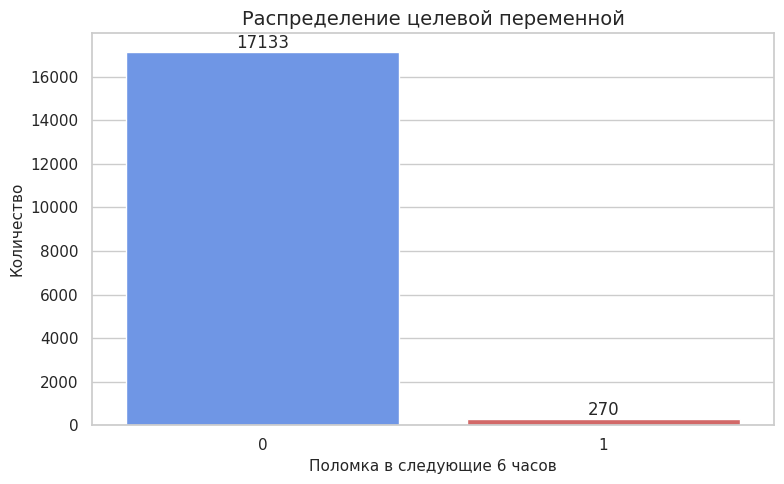

In [7]:
target_summary = (
    df["failure_next_6h"].value_counts().sort_index().rename_axis("failure_next_6h")
    .to_frame("count")
)
target_summary["percent"] = (100 * target_summary["count"] / len(df)).round(4)
display(target_summary)

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="failure_next_6h", palette=["#5B8FF9", "#E45756"], ax=ax)
ax.set(title="Распределение целевой переменной", xlabel="Поломка в следующие 6 часов", ylabel="Количество")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.show()


## 6. Пропуски и наличие сенсоров

График показывает, что пропуски связаны с комплектацией машин. Давление
доступно лишь для небольшой части оборудования, поэтому сравнения этого
показателя выполняются только по строкам, где датчик присутствует.


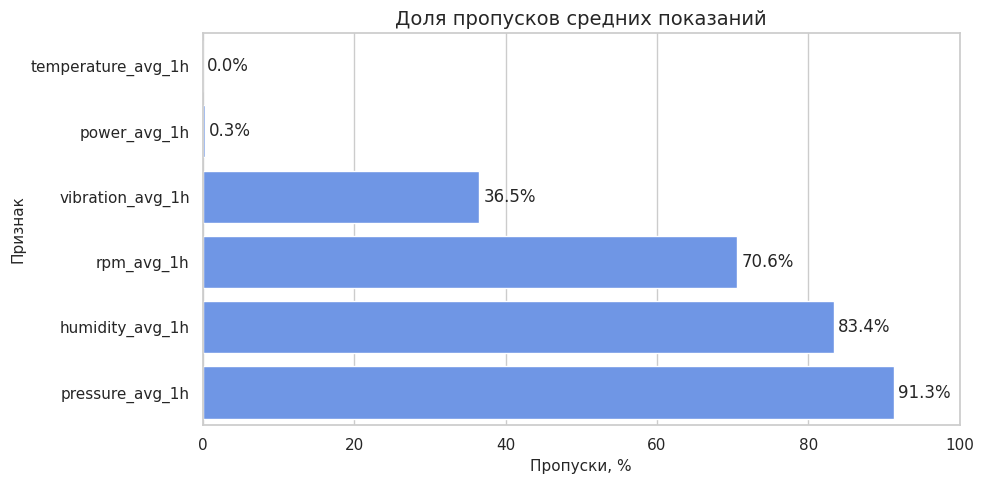

In [8]:
avg_sensor_columns = [f"{prefix}_avg_1h" for prefix in sensor_prefixes]
missing_percent = (100 * df[avg_sensor_columns].isna().mean()).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=missing_percent.values, y=missing_percent.index, color="#5B8FF9", ax=ax)
ax.set(title="Доля пропусков средних показаний", xlabel="Пропуски, %", ylabel="Признак")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


## 7. Описательная статистика

Статистика рассчитывается отдельно для штатных и предаварийных наблюдений.
Медианы устойчивее средних к редким экстремальным значениям.


In [9]:
analysis_features = [
    "temperature_avg_1h", "temperature_max_1h", "temperature_std_1h",
    "vibration_avg_1h", "power_avg_1h", "rpm_avg_1h",
    "pressure_avg_1h", "humidity_avg_1h", "breakdowns_before",
    "maintenance_last_30d",
]
descriptive = df.groupby("failure_next_6h")[analysis_features].agg(["count", "mean", "median", "std"])
display(descriptive.T)


failure_next_6h                       0          1
temperature_avg_1h   count  17,133.0000   270.0000
                     mean       88.0029    87.7235
                     median     68.3385    67.5080
                     std        44.7202    45.2243
temperature_max_1h   count  17,133.0000   270.0000
                     mean       99.7641    99.6357
                     median     79.7890    79.0261
                     std        47.1001    48.2220
temperature_std_1h   count  17,004.0000   269.0000
                     mean        5.5641     5.5922
                     median      5.2261     5.2020
                     std         1.4715     1.5162
vibration_avg_1h     count  10,865.0000   180.0000
                     mean        2.5549     2.5138
                     median      2.5058     2.5059
                     std         0.3256     0.1973
power_avg_1h         count  17,087.0000   270.0000
                     mean        2.5011     2.3581
                     median      2.5532     2.4291
                     std         1.2688     1.1888
rpm_avg_1h           count   5,025.0000    83.0000
                     mean    2,443.3575 2,384.4308
                     median  2,471.7093 2,425.7901
                     std       104.2510   148.3626
pressure_avg_1h      count   1,487.0000    21.0000
                     mean       79.9842    80.1525
                     median     80.0194    80.1088
                     std         1.0067     0.7997
humidity_avg_1h      count   2,840.0000    46.0000
                     mean       45.0298    45.1599
                     median     45.0159    45.2761
                     std         1.1720     1.0358
breakdowns_before    count  17,133.0000   270.0000
                     mean        0.7715     0.8185
                     median      0.0000     1.0000
                     std         0.9893     0.9565
maintenance_last_30d count  17,133.0000   270.0000
                     mean        0.2460     0.2593
                     median      0.0000     0.0000
                     std         0.4912     0.4948

## 8. Температура и поломки

Распределения нормированы отдельно для двух классов, иначе редкий положительный
класс был бы почти не виден. Явного смещения к более высоким температурам перед
поломками на графике не ожидается.


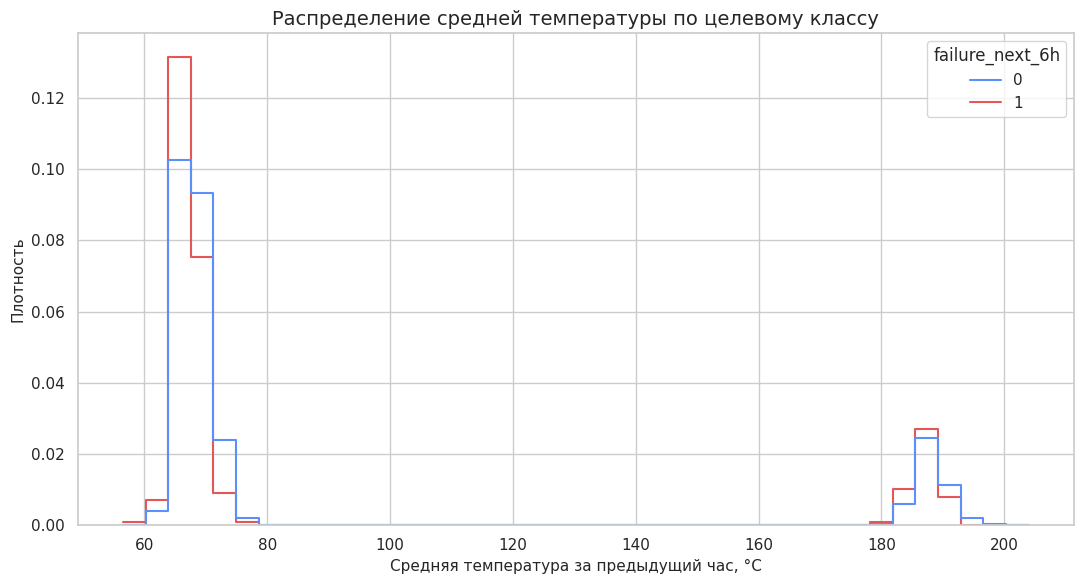

In [10]:
sns.histplot(
    data=df,
    x="temperature_avg_1h",
    hue="failure_next_6h",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    palette={0: "#5B8FF9", 1: "#E45756"},
)
plt.title("Распределение средней температуры по целевому классу")
plt.xlabel("Средняя температура за предыдущий час, °C")
plt.ylabel("Плотность")
plt.tight_layout()
plt.show()


In [11]:
temperature_risk = (
    df.assign(temperature_out_of_range=df["temperature_out_of_range_1h"] > 0)
    .groupby("temperature_out_of_range")["failure_next_6h"]
    .agg(observations="size", failures="sum", failure_rate="mean")
)
temperature_risk["failure_rate_percent"] = 100 * temperature_risk["failure_rate"]
display(temperature_risk)

display(pd.crosstab(
    df["machine_type_code"],
    df["temperature_out_of_range_1h"] > 0,
    colnames=["temperature_out_of_range"],
))


,observations,failures,failure_rate,failure_rate_percent
temperature_out_of_range,,,,
False,14517,224,0.0154,1.5430
True,2886,46,0.0159,1.5939


temperature_out_of_range,False,True
machine_type_code,,
CNC_LATHE,3117,0
CNC_MILL,1991,0
OVEN,0,2886
PACK,1964,0
PRESS,1508,0
ROBOT,3767,0
WELDER,2170,0


**Вывод.** Частота поломок при температурном превышении составляет около
1,59%, без превышения — около 1,54%. Практически все такие превышения относятся
к оборудованию типа `OVEN`, поэтому признак отражает специфику типа машины и не
доказывает влияние перегрева на поломку.


## 9. Скорость вращения и вибрация

Для этих графиков используются только строки с соответствующим сенсором.
Структурные пропуски не заполняются перед визуальным сравнением.


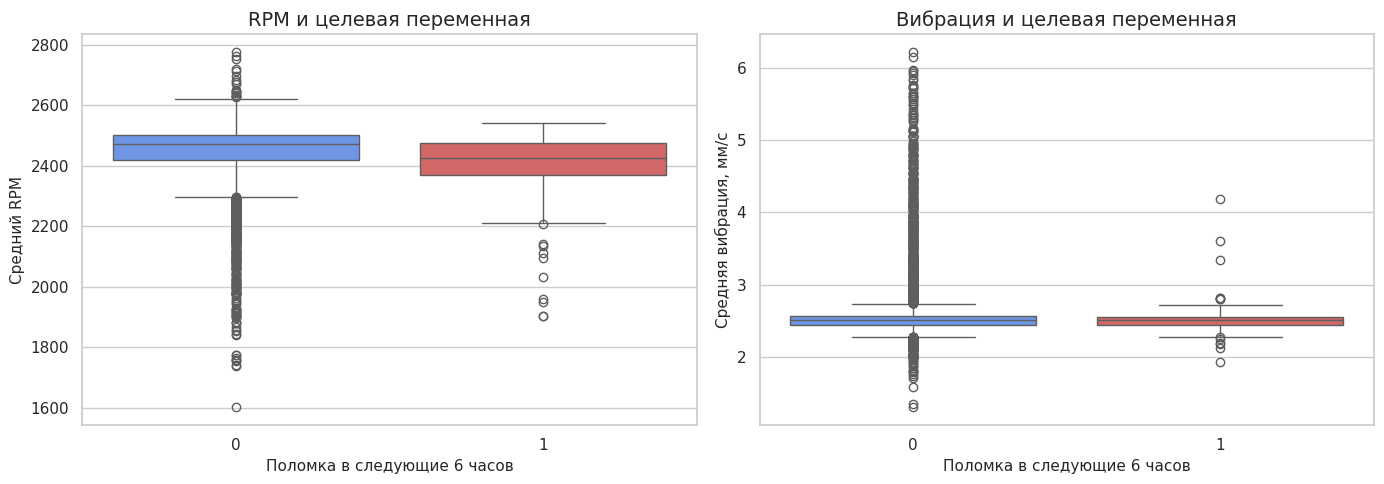

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="failure_next_6h", y="rpm_avg_1h", ax=axes[0], palette=["#5B8FF9", "#E45756"])
axes[0].set(title="RPM и целевая переменная", xlabel="Поломка в следующие 6 часов", ylabel="Средний RPM")
sns.boxplot(data=df, x="failure_next_6h", y="vibration_avg_1h", ax=axes[1], palette=["#5B8FF9", "#E45756"])
axes[1].set(title="Вибрация и целевая переменная", xlabel="Поломка в следующие 6 часов", ylabel="Средняя вибрация, мм/с")
plt.tight_layout()
plt.show()


**Вывод.** Для вибрации заметного разделения классов нет. У наблюдений перед
поломкой медианный RPM ниже: примерно 2 426 против 2 472 об/мин. Связь требует
проверки с учётом типа машины и не означает, что снижение скорости является
причиной отказа.


## 10. Совместная связь температуры и мощности

Точечная диаграмма помогает оценить форму связи двух непрерывных параметров и
проверить, образуют ли предаварийные наблюдения отдельную область.


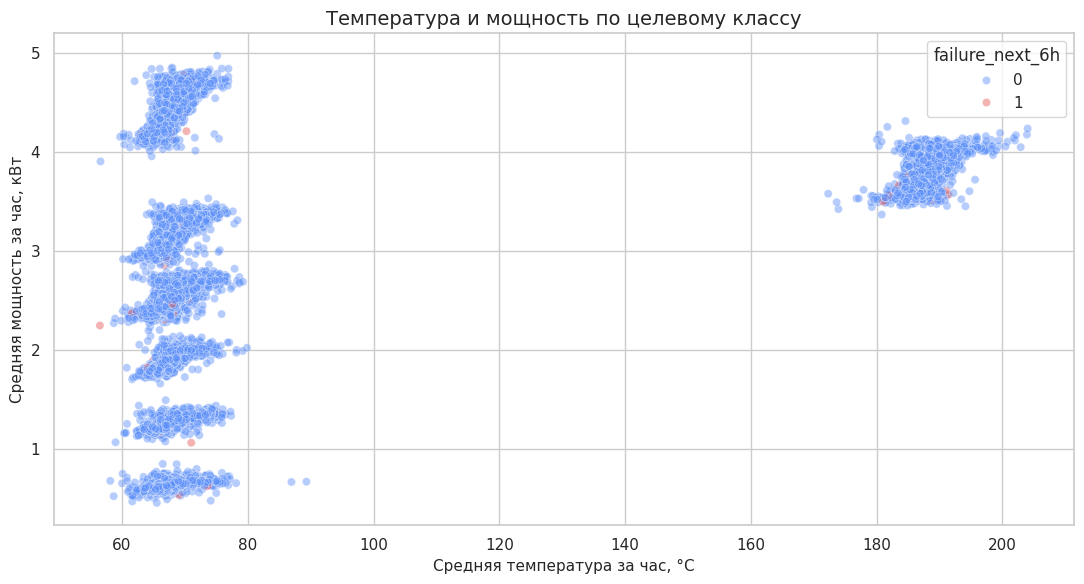

In [13]:
plot_data = df.dropna(subset=["temperature_avg_1h", "power_avg_1h"])
sns.scatterplot(
    data=plot_data,
    x="temperature_avg_1h",
    y="power_avg_1h",
    hue="failure_next_6h",
    palette={0: "#5B8FF9", 1: "#E45756"},
    alpha=0.45,
    s=35,
)
plt.title("Температура и мощность по целевому классу")
plt.xlabel("Средняя температура за час, °C")
plt.ylabel("Средняя мощность за час, кВт")
plt.tight_layout()
plt.show()


**Вывод.** Положительные наблюдения распределены внутри общей области значений;
явной линейной границы между классами нет. Следовательно, одного показателя или
простой пары показателей недостаточно для надёжного прогноза.


## 11. Частота поломок по типам машин

Сравнивается доля положительных наблюдений, а не абсолютное количество, так как
типы машин представлены разным числом строк.


,observations,failures,failure_rate,failure_rate_percent
machine_type_code,,,,
ROBOT,3767,77,0.0204,2.0441
CNC_MILL,1991,37,0.0186,1.8584
OVEN,2886,46,0.0159,1.5939
CNC_LATHE,3117,46,0.0148,1.4758
PRESS,1508,21,0.0139,1.3926
PACK,1964,23,0.0117,1.1711
WELDER,2170,20,0.0092,0.9217


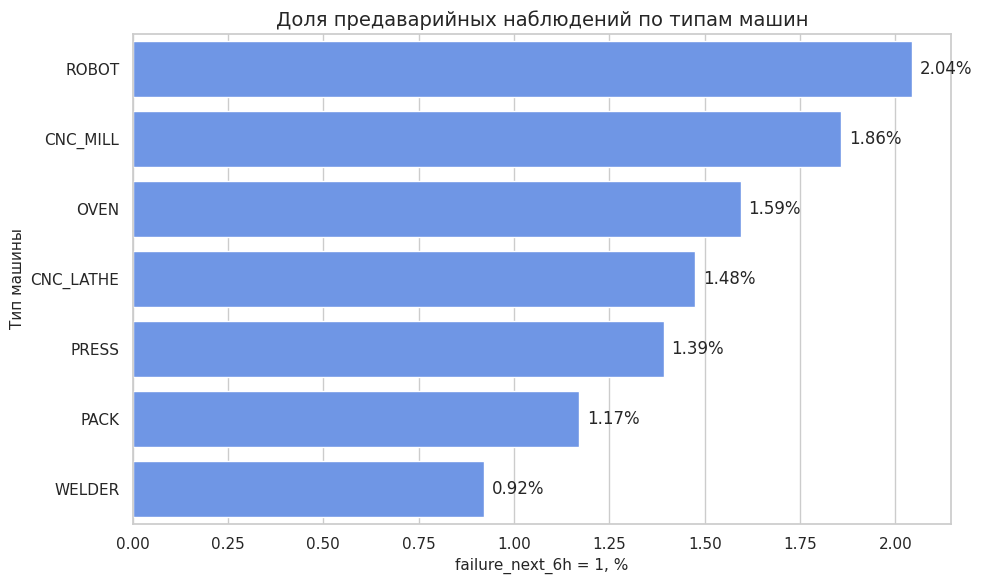

In [14]:
type_risk = (
    df.groupby("machine_type_code")["failure_next_6h"]
    .agg(observations="size", failures="sum", failure_rate="mean")
    .sort_values("failure_rate", ascending=False)
)
type_risk["failure_rate_percent"] = 100 * type_risk["failure_rate"]
display(type_risk)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=type_risk.reset_index(),
    x="failure_rate_percent",
    y="machine_type_code",
    color="#5B8FF9",
    ax=ax,
)
ax.set(title="Доля предаварийных наблюдений по типам машин", xlabel="failure_next_6h = 1, %", ylabel="Тип машины")
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.2f}%",
        va="center",
    )
plt.tight_layout()
plt.show()


**Вывод.** Наибольшая доля положительных наблюдений у `ROBOT` — около 2,04%,
наименьшая у `WELDER` — около 0,92%. Различия полезны для приоритизации анализа,
но могут отражать режим эксплуатации и частоту регистрации данных.


## 12. Корреляционная матрица

Корреляция характеризует только линейную связь и не учитывает категориальные
различия или нелинейные эффекты.


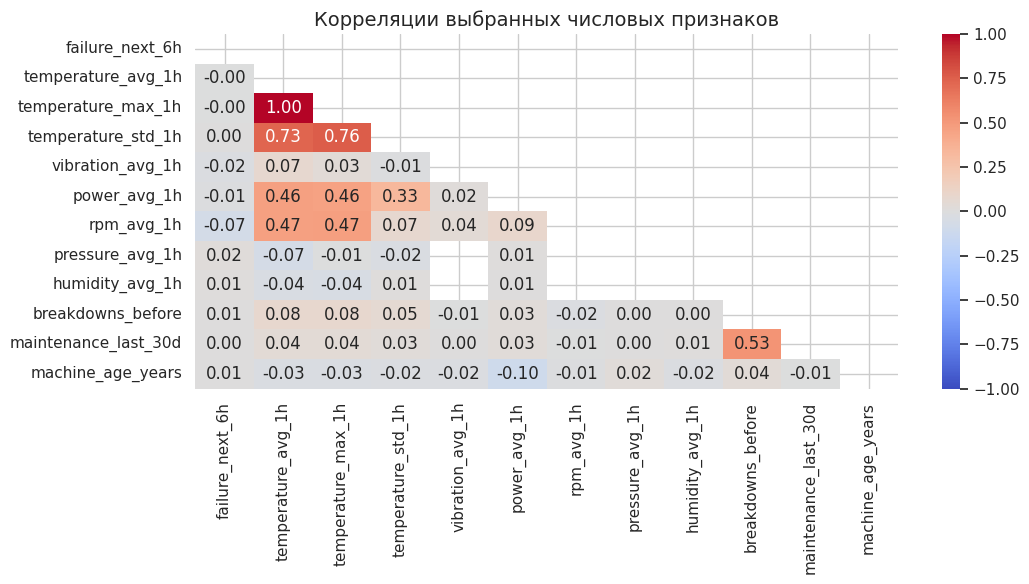

In [15]:
corr_columns = [
    "failure_next_6h", "temperature_avg_1h", "temperature_max_1h",
    "temperature_std_1h", "vibration_avg_1h", "power_avg_1h",
    "rpm_avg_1h", "pressure_avg_1h", "humidity_avg_1h",
    "breakdowns_before", "maintenance_last_30d", "machine_age_years",
]
corr = df[corr_columns].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", square=False)
plt.title("Корреляции выбранных числовых признаков")
plt.tight_layout()
plt.show()


**Вывод.** Линейные корреляции отдельных показателей с целью малы. Это означает,
что ожидаемая зависимость может быть слабой, нелинейной или проявляться только
во взаимодействиях нескольких признаков.


## 13. Проверка гипотез

Тесты имеют исследовательский характер: соседние часовые наблюдения одной
машины не полностью независимы. Здесь они помогают оценить направление и силу
связи, но не доказывают причинность.

1. **Температурное превышение повышает риск отказа.** Практический смысл —
   температурный порог для предупреждения.
2. **Высокая вибрация связана с будущей поломкой.** Практический смысл —
   раннее выявление механической нестабильности.
3. **Снижение RPM связано с будущей поломкой.** Практический смысл — контроль
   нетипичного падения скорости под нагрузкой.
4. **Риск различается между типами машин.** Практический смысл — отдельные
   пороги и регламенты обслуживания.
5. **Наличие прошлой поломки повышает будущий риск.** Практический смысл —
   усиленный контроль повторно отказавшего оборудования.


In [16]:
def rate_test(flag, target="failure_next_6h"):
    table = pd.crosstab(flag, df[target])
    chi2, p_value, _, _ = chi2_contingency(table)
    rates = df.groupby(flag)[target].mean() * 100
    return rates, p_value

def numeric_test(column):
    normal = df.loc[df["failure_next_6h"] == 0, column].dropna()
    failure = df.loc[df["failure_next_6h"] == 1, column].dropna()
    statistic, p_value = mannwhitneyu(failure, normal, alternative="two-sided")
    rank_biserial = 2 * statistic / (len(normal) * len(failure)) - 1
    return normal.median(), failure.median(), rank_biserial, p_value

temp_rates, temp_p = rate_test(df["temperature_out_of_range_1h"] > 0)
vib_0, vib_1, vib_effect, vib_p = numeric_test("vibration_avg_1h")
rpm_0, rpm_1, rpm_effect, rpm_p = numeric_test("rpm_avg_1h")

type_table = pd.crosstab(df["machine_type_code"], df["failure_next_6h"])
_, type_p, _, _ = chi2_contingency(type_table)

prior_rates, prior_p = rate_test(df["breakdowns_before"] > 0)

hypotheses = pd.DataFrame([
    {
        "hypothesis": "H1: температурное превышение повышает риск",
        "result": f"{temp_rates.get(False, np.nan):.2f}% без превышения; {temp_rates.get(True, np.nan):.2f}% с превышением",
        "p_value": temp_p,
        "conclusion": "Не подтверждена",
    },
    {
        "hypothesis": "H2: высокая вибрация повышает риск",
        "result": f"медианы {vib_0:.3f} и {vib_1:.3f} мм/с; эффект {vib_effect:.3f}",
        "p_value": vib_p,
        "conclusion": "Не подтверждена",
    },
    {
        "hypothesis": "H3: снижение RPM связано с риском",
        "result": f"медианы {rpm_0:.1f} и {rpm_1:.1f} об/мин; эффект {rpm_effect:.3f}",
        "p_value": rpm_p,
        "conclusion": "Поддерживается данными",
    },
    {
        "hypothesis": "H4: риск зависит от типа машины",
        "result": f"диапазон {type_risk.failure_rate_percent.min():.2f}%–{type_risk.failure_rate_percent.max():.2f}%",
        "p_value": type_p,
        "conclusion": "Поддерживается данными",
    },
    {
        "hypothesis": "H5: прошлая поломка повышает риск",
        "result": f"{prior_rates.get(False, np.nan):.2f}% без истории; {prior_rates.get(True, np.nan):.2f}% с историей",
        "p_value": prior_p,
        "conclusion": "Направление ожидаемое, но подтверждения недостаточно",
    },
])
hypotheses["p_value"] = hypotheses["p_value"].map(lambda value: f"{value:.6g}")
display(hypotheses)


,hypothesis,result,p_value,conclusion
0,H1: температурное превышение повышает риск,1.54% без превышения; 1.59% с превышением,0.904836,Не подтверждена
1,H2: высокая вибрация повышает риск,медианы 2.506 и 2.506 мм/с; эффект -0.041,0.347662,Не подтверждена
2,H3: снижение RPM связано с риском,медианы 2471.7 и 2425.8 об/мин; эффект -0.287,7.0415e-06,Поддерживается данными
3,H4: риск зависит от типа машины,диапазон 0.92%–2.04%,0.0194291,Поддерживается данными
4,H5: прошлая поломка повышает риск,1.40% без истории; 1.71% с историей,0.114444,"Направление ожидаемое, но подтверждения недост..."


## 14. Итоговые выводы

1. Сформирована ML-выборка из 17 403 часовых наблюдений по 96 машинам.
2. Целевой класс редкий: 270 положительных наблюдений, или 1,5515%.
3. Пропуски большей части сенсорных признаков структурные и отражают комплектацию
   оборудования; удаление строк не применяется.
4. Температурные превышения не показали самостоятельного роста риска и совпали
   с типом оборудования `OVEN`.
5. Высокая вибрация не показала статистически заметной связи с целью.
6. Наиболее выраженный числовой результат — более низкий RPM перед поломкой;
   его необходимо перепроверить с учётом типа машины.
7. Частота положительного класса различается по типам машин: примерно от 0,92%
   до 2,04%.
8. Для дальнейшей модели следует использовать хронологическое разделение,
   индикаторы наличия сенсоров, устойчивую обработку пропусков и метрики Recall,
   F1 и PR-AUC. Из-за слабых одиночных связей предпочтительны модели, способные
   учитывать нелинейные взаимодействия признаков.
